# EEG Signal Processing and Classification Pipeline

This project implements a complete EEG processing pipeline using the MNE library, including:
- Raw EEG signal acquisition (EDF files)
- Preprocessing (filtering, ICA artifact removal, channel selection)
- Epoching into fixed-length segments
- Feature extraction (time + frequency + wavelet features)
- Machine learning classification (SVM, KNN, RF, Logistic Regression, LDA)
- Deep learning models (CNN, LSTM/GRU hybrid architectures)
- Evaluation using cross-validation and multiple performance metrics

The goal is to build a robust EEG-based classification system for neurological disorder detection using both traditional machine learning and deep learning approaches.

<div class="alert alert-block alert-success">
<h1>EEG Data Aquisition with MNE</h1>
</div>

We always start by importing libraries and loading the file 

In [1]:
# =========================
# LIBRARIES
# =========================
%matplotlib inline

import os
import re
import glob
import numpy as np
import mne
import pywt

from scipy import stats
from scipy.signal import welch
from tqdm import tqdm

# 1.Preprocessing

Then we write the functions we are going to use to do the preprocessing and epoching of the data

In [2]:
for my case the edf files are located in mne_data/edf/Abby_Resting.edf
all_file_path = glob("epilepsy dataset/chb01_03/*.edf") # all_file_path is array contain all the 10 edf files

def epoching(file_path):
    data = mne.io.read_raw_edf(file_path,preload=True) #read the edf file
    data.set_montage('standard_1020') # set montage for the raw file needed because digitlized point are not in the info
    data.resample(256, npad="auto")    # In case you need to resampling frequency 
   # data.pick_channels(['Fp1','Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'C3', 'Cz', 'C4', 'T7', 'T8', 'P3', 'P4', 'P7', 'P8'])
    data.filter(l_freq=0.5,h_freq=40) # filter low freq = 0.5 hz and h_freq = 40 
    epochs=mne.make_fixed_length_epochs(data, duration=10,overlap=0) # change in duration if you want but must be equal or you loose data
    return epochs.load_data()

def preprocessing(sample_data):
    ica = mne.preprocessing.ICA(n_components=10, max_iter='auto', random_state=97)
    ica.fit(sample_data)
    ica.plot_sources(sample_data); # the plot function if you want to remove it
    muscle_idx_auto, scores = ica.find_bads_muscle(sample_data)
    ica.exclude = muscle_idx_auto 
    ica.apply(sample_data.load_data())
    return sample_data.load_data()

Here we are going to apply the ICA and data epoching and save then in an offline database

In [ ]:
healthy_epoching_data = [epoching(i) for i in epilepsy_pick_data]

Fitting ICA to data using 16 channels (please be patient, this may take a while)
Using data from preloaded Raw for 360 events and 2560 original time points ...
0 bad epochs dropped
Selecting by number: 10 components
Using data from preloaded Raw for 360 events and 2560 original time points ...
Fitting ICA took 16.5s.
Using data from preloaded Raw for 360 events and 2560 original time points ...
Not setting metadata
360 matching events found
No baseline correction applied
0 projection items activated


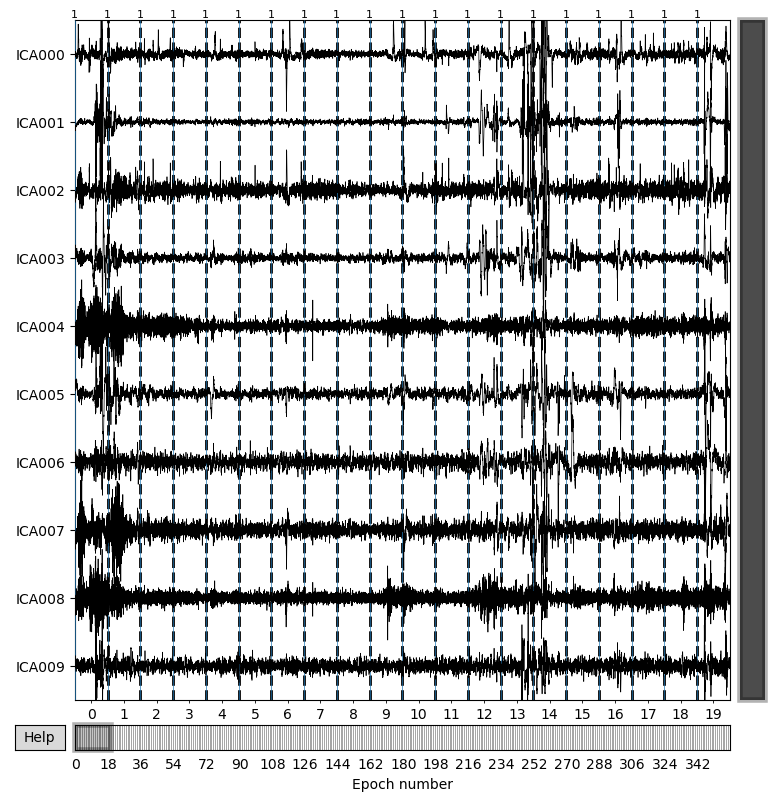

Using data from preloaded Raw for 360 events and 2560 original time points ...
    Using multitaper spectrum estimation with 7 DPSS windows
Using data from preloaded Raw for 360 events and 2560 original time points ...
Applying ICA to Epochs instance
    Transforming to ICA space (10 components)
    Zeroing out 6 ICA components
    Projecting back using 16 PCA components


In [21]:
file=0
for i in epilepsy_pick_data:
    epochs = preprocessing(i)
    epochs.set_meas_date(None)  # Set the meas_date using the creation time of the object
    for j in range(36,342):
        epochs[j].save("seizure/seg10/"+f'normal_S_{file}_Ep_{j}-epo.fif', overwrite=True)
    file+=1

# 1.1.Channel rename

This step is used specially on the CHB-MIT dataset to rename the channels since they come in the form of (FP1-F7). 

In [3]:
import re

def chb_data(edf_file_name):
    replace_dict = {}
    drop_list = []
    data = mne.io.read_raw_edf(edf_file_name,preload=True) #read the edf file
    for channel_name in data.info['ch_names']:
        # get the name to change too
        name_change = re.findall('\w+',channel_name)[0].title()
        # check if it is already in the change list
        if name_change in list(replace_dict.values()):
            drop_list.append(channel_name)
        else:
            # if its not already there get the origional name and what we want to
            # change it to
            replace_dict[channel_name] = name_change

    # drop the ones that would be repeats
    data.drop_channels(drop_list)
    # rename the channels
    data.rename_channels(replace_dict)
    # set the standard montage
    return data


In [4]:
def pick_data(data):
	data.pick_channels(['Fp1','Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'C3', 'Cz', 'C4', 'T7', 'T8', 'P3', 'P4', 'P7', 'P8'])
	data.filter(l_freq=0.5,h_freq=40) # filter low freq = 0.5 hz and h_freq = 40
	data.set_montage('standard_1020') # set montage for the raw file needed because digitlized point are not in the info
	epochs=mne.make_fixed_length_epochs(data,duration=10,overlap=0) # change in duration if you want but must be equal or you loose data
	return epochs


In [74]:
all_file_path = glob("seizure/*.edf")

In [75]:
epilepsy_rename = [chb_data(i) for i in all_file_path]

Extracting EDF parameters from C:\Users\SOUHAILA\Downloads\seizure\chb08_21.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


C:\Users\SOUHAILA\AppData\Local\Temp\ipykernel_744\2421027688.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(edf_file_name,preload=True) #read the edf file


In [76]:
epilepsy_pick_data = [pick_data(i) for i in epilepsy_rename]

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s


Not setting metadata
360 matching events found
No baseline correction applied
0 projection items activated


[Parallel(n_jobs=1)]: Done  16 out of  16 | elapsed:    0.4s finished


Fitting ICA to data using 16 channels (please be patient, this may take a while)
Using data from preloaded Raw for 360 events and 2560 original time points ...
0 bad epochs dropped
Selecting by number: 10 components
Using data from preloaded Raw for 360 events and 2560 original time points ...
Fitting ICA took 10.8s.
Using data from preloaded Raw for 360 events and 2560 original time points ...
Not setting metadata
360 matching events found
No baseline correction applied
0 projection items activated


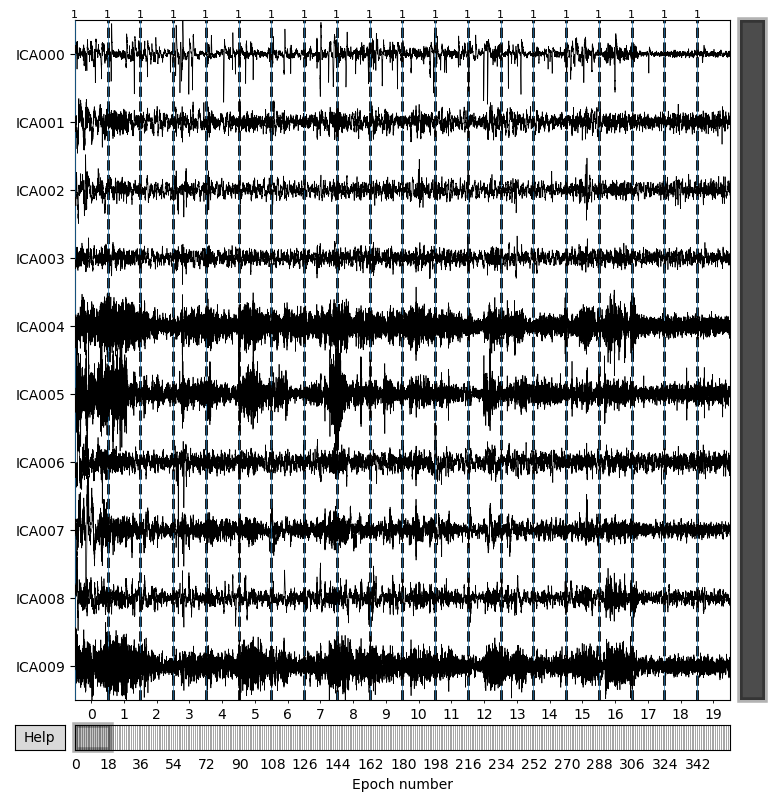

Using data from preloaded Raw for 360 events and 2560 original time points ...
    Using multitaper spectrum estimation with 7 DPSS windows
Using data from preloaded Raw for 360 events and 2560 original time points ...
Applying ICA to Epochs instance
    Transforming to ICA space (10 components)
    Zeroing out 8 ICA components
    Projecting back using 16 PCA components


In [77]:
file=0
for i in epilepsy_pick_data:
    epochs = preprocessing(i)
    epochs.set_meas_date(None)  # Set the meas_date using the creation time of the object
    for j in range(208,238):
        epochs[j].save("seizure/seg10/"+f'normal_S_3_Ep_{j}-epo.fif', overwrite=True)
    file+=1

# 1.2.Plotting propreties

This step we plotted the propreties of ICA  

In [ ]:
def read_unprocessed_data(file_path):
    data = mne.io.read_raw_edf(file_path,preload=True) #read the edf file
    data.pick_channels(['Fp1','Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'C3', 'Cz', 'C4', 'T7', 'T8', 'P3', 'P4', 'P7', 'P8'])
    data.crop(tmin=10, tmax=20)
    data.plot()
    data.set_montage('standard_1020') # set montage for the raw file needed because digitlized point are not in the info
    #data.resample(256, npad="auto")    # In case you need to resampling frequency 
    ica = mne.preprocessing.ICA(n_components=10, max_iter='auto', random_state=97)
    ica.fit(data)
    os.makedirs(f'ICA preprocessing {file_path}')
    muscle_idx_auto, scores = ica.find_bads_muscle(data)
    j=0
    for i in ica.plot_properties(data):
        j=j+1
        i.savefig(f'ICA preprocessing {file_path}\\' + f'ICA component {j} signal.png')
    ica.plot_sources(data, show_scrollbars=False).savefig(f'ICA preprocessing {file_path}\\' + 'ICA signals.png')

In [ ]:
all_file_path = glob("healthy dataset/*.edf") # all_file_path is array contain all the 10 edf files

for i in all_file_path:
    read_unprocessed_data(i)

This step we plotted the PSD and Topomap  

In [ ]:
def epoch_data_viz(file_path):
    data = mne.read_epochs(file_path,preload=True) #read the epochs
    data.pick_channels(['Fp1','Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'C3', 'Cz', 'C4', 'T7', 'T8', 'P3', 'P4', 'P7', 'P8'])
    data.set_montage('standard_1020') # set montage for the raw file needed because digitlized point are not in the info
    os.makedirs(f'after preprocessing1 {file_path}')
    data.crop(tmin=10, tmax=20)
    data.plot().savefig(f'after preprocessing1 {file_path}\\' + ' raw signal.png')
    data.plot_sensors(title="Sensor Location",show_names=True).savefig(f'After preprocessing {file_path}\\' + 'Sensor Location.png')
    data.compute_psd().plot().savefig(f'After preprocessing {file_path}\\' + ' EEG PSD.png')
    data.compute_psd().plot_topomap().savefig(f'After preprocessing {file_path}\\' + 'Activity .png')
    data.plot_topo_image().savefig(f'After preprocessing {file_path}\\' + 'Topo image .png')

In [ ]:
all_file_path = glob("autism dataset\*.edf") # all_file_path is array contain all the 10 edf files

for i in range(1,2):
    read_file_viz(all_file_path[i])

# 2.Feature extraction

First we are going to read the data from the offline database 

Added Part 

In [2]:
channels_to_pick = ["Fz", "Cz", "Pz"]
def read_epoched_data(file_path):
    data = mne.read_epochs(file_path,preload=True) #read the epochs
    picked_data = data.pick_channels(channels_to_pick)
    array = picked_data.get_data()
    return array

In [79]:
channels_to_pick = ["Fz", "Cz", "Pz"]
def read_epoched_data(file_path):
    data = mne.read_epochs(file_path,preload=True) #read the epochs
    picked_data = data.pick_channels(channels_to_pick)
    array = picked_data.get_data()
    coeffs_list = []
    for epoch in array:
        coeffs = pywt.wavedec(epoch, 'db4', level=5, axis=-1)
        coeffs_list.append(np.hstack(coeffs))
    epochs = np.array(coeffs_list)
    return epochs

In [3]:
#put path of epoching files of each one
healthy_path    = glob("seizure/seg10/*-epo.fif")
scizo_path     = glob("schizo/ch19/*-epo.fif")
autistic_path  = glob("autism dataset/seg40/*-epo.fif")
epileptic_path = glob("epilepsy_no_seizures/seg10/*-epo.fif")

health_data_array     = [read_epoched_data(subject) for subject in healthy_path]
scizo_data_array      = [read_epoched_data(subject) for subject in scizo_path]
autistic_data_array   = [read_epoched_data(subject) for subject in autistic_path]
epileptic_data_array  = [read_epoched_data(subject) for subject in epileptic_path]

Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_108-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_109-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_110-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_111-epo.fif ...
    Foun

Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_233-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_234-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_235-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_236-epo.fif ...
    Foun

Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_337-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_338-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_339-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_0_Ep_36-epo.fif ...
    Found

    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_1_Ep_234-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_1_Ep_235-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_1_Ep_236-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF c

    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_2_Ep_286-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_2_Ep_287-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\seizure\seg10\normal_S_2_Ep_288-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    9996.09 ms
        0 CTF c

...

    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_1_Ep_20-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_1_Ep_21-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_1_Ep_22-epo.fif ...
    Found the data of interest:
        t =       0.

    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_3_Ep_10-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_3_Ep_11-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_3_Ep_12-epo.fif ...
    Found the data of interest:
        t =       0.

    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_4_Ep_18-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_4_Ep_19-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_4_Ep_20-epo.fif ...
    Found the data of interest:
        t =       0.

    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_5_Ep_8-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_5_Ep_9-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_6_Ep_10-epo.fif ...
    Found the data of interest:
        t =       0.00

    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_7_Ep_16-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_7_Ep_17-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    4996.09 ms
        0 CTF compensation matrices available
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\SOUHAILA\Downloads\epilepsy_no_seizures\seg10\normal_S_7_Ep_18-epo.fif ...
    Found the data of interest:
        t =       0.

Then we are going to put it into a matrix 

In [4]:
health_epochs_labels      = [len(i)*[0] for i in health_data_array]
scizo_epochs_labels       = [len(i)*[1] for i in scizo_data_array]
autistic_epochs_labels    = [len(i)*[2] for i in autistic_data_array]
epileptic_epochs_labels   = [len(i)*[1] for i in epileptic_data_array]
print(len(health_epochs_labels),len(epileptic_epochs_labels))len(epileptic_epochs_labels),len(autistic_epochs_labels))#

188 144


In [5]:
data_list   =  health_data_array+epileptic_data_array+scizo_data_array+autistic_data_array#
label_list  =  health_epochs_labels+epileptic_epochs_labels+scizoc_epochs_labelsautistic_epochs_labels#
print(len(data_list),len(label_list))

332 332


In [6]:
groups_list=[[i]*len(j) for i, j in enumerate(data_list)]

In [7]:
max_length = max([array.shape[2] for array in data_list])  # get maximum length along the third dimension
padded_data_list = []
for array in data_list:
    if array.shape[2] < max_length:
        pad_width = [(0, 0), (0, 0), (0, max_length - array.shape[2])]  # padding for the third dimension
        padded_array = np.pad(array, pad_width, mode='constant', constant_values=0)  # pad with zeros
    else:
        padded_array = array[:, :, :max_length]  # truncate to maximum length along the third dimension
    padded_data_list.append(padded_array)

In [8]:
data_array=np.vstack(padded_data_list)
label_array=np.hstack(label_list)
group_array=np.hstack(groups_list)
print(data_array.shape,label_array.shape,group_array.shape)

(332, 2, 2560) (332,) (332,)


Here we have the wavelet code : DB4

In [97]:
from sklearn.feature_selection import mutual_info_classif
def compute_wavelet_coeffs(signal, wavelet='db4'):
    """
    Computes the wavelet coefficients of a given signal.
    """
    level=4
    coeffs = pywt.wavedec(signal, wavelet,level=level)
    return np.concatenate(coeffs)

Here we have the feature such as skewness, kurtosis, shannon entropy, bandpower, pwelch and standard deviation

In [98]:
from tqdm import tqdm_notebook
from scipy.stats import entropy
from scipy import stats
def kurtosis(data):
    return stats.kurtosis(data,axis=-1)

from scipy.signal import welch

def concatenate_features(data, fs):
    features = []
    freq_bands = [(0.5, 4), (4, 8), (8, 13), (13, 30), (30, 40)]
    
    for channel in data:
        # Time-domain features
        features.append(np.mean(channel))
#         features.append(np.std(channel))
#         features.append(np.ptp(channel))
#         features.append(np.var(channel))
 #       features.append(np.min(channel))
#        features.append(np.max(channel))
#         features.append(np.argmin(channel))
#         features.append(np.argmax(channel))
#         features.append(np.mean(channel**2))
#         features.append(np.sqrt(np.mean(channel**2)))
        features.append(np.sum(np.abs(np.diff(channel))))
        features.append(stats.skew(channel))
        features.append(stats.kurtosis(channel))
        
        # Shannon entropy
        hist, _ = np.histogram(channel, bins=50, density=True)
        probs = hist / np.sum(hist)
        entropy = -np.sum(probs * np.log2(probs + (probs == 0)))
        features.append(entropy)
        
        # Frequency-domain features
        f, psd = welch(channel, fs=fs, nperseg=fs*2)
        for band in freq_bands:
            freq_ix = np.where((f >= band[0]) & (f <= band[1]))[0]
            band_power = np.trapz(psd[freq_ix], f[freq_ix])
            features.append(band_power)
    
    return np.array(features)

Here we are applying the features on the data

In [99]:
from tqdm import tqdm_notebook
features=[]
for data in tqdm_notebook(data_array):
    features.append(concatenate_features(data,256))
features=np.array(features)
features.shape

C:\Users\SOUHAILA\AppData\Local\Temp\ipykernel_744\3855776169.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for data in tqdm_notebook(data_array):


  0%|          | 0/332 [00:00<?, ?it/s]

(332, 160)

# 3. Machine Learning classification

Machine learning Libraries

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold,GridSearchCV,cross_val_score,cross_validate 
from joblib import dump,load

This is the KNN model

In [110]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
gkf = GroupKFold(n_splits=5)
param_grid = {'classifier__n_neighbors': [  3, 4, 5, 6, 7, 8, 9, 10]}
pipe = Pipeline([('scaler', StandardScaler()), ('classifier', clf)])
gscv = GridSearchCV(pipe, param_grid, cv=gkf, n_jobs=16)
gscv.fit(features, label_array, groups=group_array)

GridSearchCV(cv=GroupKFold(n_splits=5),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=16,
             param_grid={'classifier__n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10]})

This is the Regression model

In [108]:
clf=LogisticRegression()
gkf=GroupKFold(n_splits=5)
param_grid = {'classifier__C': [0.01,0.05,0.1,0.5, 1,2,3,4,5,8, 10,12,15]}
pipe=Pipeline([('scaler',StandardScaler()),('classifier',clf)])
gscv=GridSearchCV(pipe,param_grid,cv=gkf,n_jobs=16)
gscv.fit(features,label_array,groups=group_array)

GridSearchCV(cv=GroupKFold(n_splits=5),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier', LogisticRegression())]),
             n_jobs=16,
             param_grid={'classifier__C': [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5,
                                           8, 10, 12, 15]})

This is the SVM model

In [101]:
from sklearn.svm import SVC

clf = SVC()
gkf = GroupKFold(n_splits=5)
param_grid = {'classifier__C': [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5, 8, 10, 12, 15],
              'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid']}
pipe = Pipeline([('scaler', StandardScaler()), ('classifier', clf)])
gscv = GridSearchCV(pipe, param_grid, cv=gkf, n_jobs=16)
gscv.fit(features, label_array, groups=group_array)


GridSearchCV(cv=GroupKFold(n_splits=5),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier', SVC())]),
             n_jobs=16,
             param_grid={'classifier__C': [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5,
                                           8, 10, 12, 15],
                         'classifier__kernel': ['linear', 'poly', 'rbf',
                                                'sigmoid']})

this is the LDA model

In [103]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
clf = LinearDiscriminantAnalysis()
gkf = GroupKFold(n_splits=5)

param_grid = {'classifier__n_components': [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5, 8, 10, 12, 15]}

pipe = Pipeline([('scaler', StandardScaler()), ('classifier', clf)])
gscv = GridSearchCV(pipe, param_grid, cv=gkf, n_jobs=16)

gscv.fit(features, label_array, groups=group_array)

C:\Users\SOUHAILA\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
60 fits failed out of a total of 65.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\SOUHAILA\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\SOUHAILA\anaconda3\lib\site-packages\sklearn\pipeline.py", line 405, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "C:\Users\SOUHAILA\anaconda3\lib\site-packages\sklearn\discriminant_analysis.py", line 571, in fit
    self._validate_params()
  File "C:\Users\

GridSearchCV(cv=GroupKFold(n_splits=5),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        LinearDiscriminantAnalysis())]),
             n_jobs=16,
             param_grid={'classifier__n_components': [0.01, 0.05, 0.1, 0.5, 1,
                                                      2, 3, 4, 5, 8, 10, 12,
                                                      15]})

This is the Random forest model 

In [105]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

gkf=GroupKFold(n_splits=5)

param_grid = {
    'classifier__n_estimators': [100, 300, 500],
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

pipe = Pipeline([('scaler', StandardScaler()), ('classifier', rf)])
gscv = GridSearchCV(pipe, param_grid, cv=gkf, n_jobs=16)
gscv.fit(features, label_array, groups=group_array)


GridSearchCV(cv=GroupKFold(n_splits=5),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        RandomForestClassifier())]),
             n_jobs=16,
             param_grid={'classifier__max_depth': [None, 5, 10, 20],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 300, 500]})

In [111]:
gscv.best_score_  


0.9819086386250564

Here we have the confusion matrix code

In [107]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# make predictions on the test set
y_pred = gscv.predict(features)

# Create the confusion matrix
cm = confusion_matrix(label_array, y_pred)

# Get the number of classes
num_classes = cm.shape[0]

# Print the confusion matrix
print('Confusion Matrix')
for i in range(num_classes):
    row = ''
    for j in range(num_classes):
        row += str(cm[i,j]) + '\t'
    print(row)
    
# Print the classification report
from sklearn.metrics import classification_report
report = classification_report(label_array, y_pred)
print('\nClassification Report')
print(report)


Confusion Matrix
188	0	
0	144	

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       188
           3       1.00      1.00      1.00       144

    accuracy                           1.00       332
   macro avg       1.00      1.00      1.00       332
weighted avg       1.00      1.00      1.00       332



# 4.Deep Learning Classification 

In [9]:
data_array=np.vstack(padded_data_list)
label_array=np.hstack(label_list)
group_array=np.hstack(groups_list)
data_array=np.moveaxis(data_array,1,2)
print(data_array.shape,label_array.shape,group_array.shape)

(332, 2560, 2) (332,) (332,)


In [10]:
import numpy as np
data_array=np.concatenate(padded_data_list)
label_array=np.concatenate(label_list)
group_array=np.concatenate(groups_list)
data_array=np.moveaxis(data_array,1,2)

print(data_array.shape,label_array.shape,group_array.shape)

(332, 2560, 2) (332,) (332,)


# Chrononet  Model

In [21]:
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Input, concatenate, GRU
from keras.models import Model
from keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D,BatchNormalization,LeakyReLU,MaxPool1D,\
 GlobalAveragePooling1D,Dense,Dropout,AveragePooling1D, SpatialDropout1D, AvgPool1D, LSTM, Flatten, MaxPooling1D, Conv2D, DepthwiseConv2D,\
 Activation, AveragePooling2D, SeparableConv2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.backend import clear_session
from keras.callbacks import EarlyStopping
from keras import regularizers

def block(input):
    conv1 = Conv1D(32, 3, strides=2, activation='elu', padding="same",
                   kernel_regularizer=regularizers.l2(0.01))(input)
    conv1 = BatchNormalization()(conv1)

    conv2 = Conv1D(32, 3, strides=2, activation='elu', padding="causal",
                   kernel_regularizer=regularizers.l2(0.01))(input)
    conv2 = BatchNormalization()(conv2)

    conv3 = Conv1D(32, 3, strides=2, activation='elu', padding="causal",
                   kernel_regularizer=regularizers.l2(0.01))(input)
    #conv3 = BatchNormalization()(conv3)

    x = concatenate([conv1, conv2, conv3], axis=2)
    return x

def cnnmodel():
    clear_session()
    input = Input(shape=(2560, 2))
    block1 = block(input)
    block2 = block(block1)
    block3 = block(block2)
    gru_out1 = LSTM(32, activation='tanh', return_sequences=True,
                    kernel_regularizer=regularizers.l2(0.01))(block3)
    gru_out2 = GRU(32, activation='tanh', return_sequences=True,
                    kernel_regularizer=regularizers.l2(0.01))(gru_out1)
    gru_out = concatenate([gru_out1, gru_out2], axis=2)
    gru_out3 = GRU(32, activation='tanh', return_sequences=True,
                    kernel_regularizer=regularizers.l2(0.01))(gru_out)
    gru_out = concatenate([gru_out1, gru_out2, gru_out3], axis=2)
    gru_out4 = GRU(32, activation='tanh', return_sequences=True,
                    kernel_regularizer=regularizers.l2(0.01))(gru_out)
    gru_out5 = GRU(32, activation='tanh', return_sequences=True,
                    kernel_regularizer=regularizers.l2(0.01))(gru_out4)
    gru_out_cv = concatenate([gru_out1,gru_out5, gru_out4], axis=2)
    gru_out6 = GRU(32, activation='tanh',
                    kernel_regularizer=regularizers.l2(0.01))(gru_out_cv)
    predictions = Dense(2, activation='softmax')(gru_out6)
    model = Model(inputs=input, outputs=predictions)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = cnnmodel()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 2560, 2)]    0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 1280, 32)     224         ['input_1[0][0]']                
                                                                                                  
 conv1d_1 (Conv1D)              (None, 1280, 32)     224         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 1280, 32)    128         ['conv1d[0][0]']                 
 alization)                                                                                   

The CNN model using Tensorflow keras.
the architecture is constructed of convolutional 1D layers, LeakyRelu,max pooling, average pooling and fully connected layers

In [13]:
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
gkf=GroupKFold()

In [23]:
data_array.shape

(332, 2560, 2)

Added Part

In [24]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, f1_score, matthews_corrcoef
'''
TP : the number of segments that are correctly identified as ictal (x_true == x_pred == 1)
TN : the number of EEG segments that are correctly classified as non-ictal (x_true == x_pred == 0)
FP : the number of EEG segments that are incorrectly classified as ictal (x_true == 0 && x_pred == 1)
FN : the segments that are incorrectly classified as non-ictal (x_true == 1 && x_pred == 0)
'''
def classificationPerformanceIndexes (true_arr, pred_arr):
    (tn, fp, fn, tp) = confusion_matrix(true_arr, pred_arr).ravel()
    acc = accuracy_score(true_arr, pred_arr)                           # Accuracy
    snv = tp/(tp + fn)                                                 # Sensitivity or True Positive Rate (TPR)
    spc = tn/(tn + fp)                                                 # Specificity or True Negative Rate (TNR)
    ppv = tp/(tp + fp)                                                 # Precision or Positive Predictive Value (PPV)
    f1 = f1_score(true_arr, pred_arr)                                  # F1 score
    mcc = matthews_corrcoef(true_arr, pred_arr)                        # Matthews Correlation Coefficient
    kappa = cohen_kappa_score(true_arr, pred_arr)                      # Cohen’s Kappa    
    return acc, snv, spc, ppv, f1, mcc, kappa

In [25]:
accuracy=[]
snv_list, spc_list, ppv_list, f1_list, mcc_list, kappa_list = [], [], [], [], [], []
for train_index, val_index in gkf.split(data_array, label_array, groups=group_array):
    train_features,train_labels=data_array[train_index],label_array[train_index]
    val_features,val_labels=data_array[val_index],label_array[val_index]
    scaler=StandardScaler()
    train_features = scaler.fit_transform(train_features.reshape(-1, train_features.shape[-1])).reshape(train_features.shape)
    val_features = scaler.transform(val_features.reshape(-1, val_features.shape[-1])).reshape(val_features.shape)
    model = cnnmodel()
    model.fit(train_features,train_labels,epochs=30,batch_size=128,validation_data=(val_features,val_labels))
    predictions = model.predict(val_features)
    
    accuracy.append(model.evaluate(val_features,val_labels)[1])
    predicted_labels = (predictions > 0.5).astype(int)  # Assuming binary classification and a threshold of 0.5

    # Calculate classification metrics
    acc, snv, spc, ppv, f1, mcc, kappa = classificationPerformanceIndexes(val_labels, predicted_labels)

    accuracy.append(acc)
    snv_list.append(snv)
    spc_list.append(spc)
    ppv_list.append(ppv)
    f1_list.append(f1)
    mcc_list.append(mcc)
    kappa_list.append(kappa)

    # Additional metrics
    rmsd = root_mean_squared_error(val_labels, predicted_labels)
    snr = signal_to_noise_ratio(val_labels, predicted_labels)
    mse = mean_squared_error(val_labels, predicted_labels)

    # Print or store additional metrics as needed
    print("RMSD:", rmsd)
    print("SNR:", snr)
    print("MSE:", mse)

Epoch 1/30
3/3 [==============================] - 21s 3s/step - loss: 8.3641 - accuracy: 0.6038 - val_loss: 8.0716 - val_accuracy: 0.9254
Epoch 2/30
3/3 [==============================] - 5s 1s/step - loss: 7.7904 - accuracy: 0.9057 - val_loss: 7.6790 - val_accuracy: 0.9403
Epoch 3/30
3/3 [==============================] - 5s 1s/step - loss: 7.3910 - accuracy: 0.9472 - val_loss: 7.3173 - val_accuracy: 0.9701
Epoch 4/30
3/3 [==============================] - 6s 2s/step - loss: 7.0158 - accuracy: 0.9811 - val_loss: 6.9874 - val_accuracy: 0.9851
Epoch 5/30
3/3 [==============================] - 6s 2s/step - loss: 6.6924 - accuracy: 0.9887 - val_loss: 6.6930 - val_accuracy: 1.0000
Epoch 6/30
3/3 [==============================] - 6s 2s/step - loss: 6.4045 - accuracy: 0.9925 - val_loss: 6.4860 - val_accuracy: 0.5672
Epoch 7/30
3/3 [==============================] - 6s 2s/step - loss: 6.1252 - accuracy: 0.9962 - val_loss: 6.1439 - val_accuracy: 1.0000
Epoch 8/30
3/3 [========================

ValueError: Classification metrics can't handle a mix of binary and multilabel-indicator targets

In [35]:
accuracy

[0.9552238583564758,
 0.9850746393203735,
 0.9696969985961914,
 1.0,
 0.9545454382896423]

Added Part

In [ ]:
# Print or store the aggregated results as needed
print("Average Accuracy:", np.mean(accuracy))
print("Average SNV:", np.mean(snv_list))
print("Average SPC:", np.mean(spc_list))
print("Average PPV:", np.mean(ppv_list))
print("Average F1:", np.mean(f1_list))
print("Average MCC:", np.mean(mcc_list))
print("Average Kappa:", np.mean(kappa_list))

In [41]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, f1_score, matthews_corrcoef
'''
TP : the number of segments that are correctly identified as ictal (x_true == x_pred == 1)
TN : the number of EEG segments that are correctly classified as non-ictal (x_true == x_pred == 0)
FP : the number of EEG segments that are incorrectly classified as ictal (x_true == 0 && x_pred == 1)
FN : the segments that are incorrectly classified as non-ictal (x_true == 1 && x_pred == 0)
'''
def classificationPerformanceIndexes (true_arr, pred_arr):
    (tn, fp, fn, tp) = confusion_matrix(true_arr, pred_arr).ravel()
    acc = accuracy_score(true_arr, pred_arr)                           # Accuracy
    snv = tp/(tp + fn)                                                 # Sensitivity or True Positive Rate (TPR)
    spc = tn/(tn + fp)                                                 # Specificity or True Negative Rate (TNR)
    ppv = tp/(tp + fp)                                                 # Precision or Positive Predictive Value (PPV)
    f1 = f1_score(true_arr, pred_arr)                                  # F1 score
    mcc = matthews_corrcoef(true_arr, pred_arr)                        # Matthews Correlation Coefficient
    kappa = cohen_kappa_score(true_arr, pred_arr)                      # Cohen’s Kappa    
    return acc, snv, spc, ppv, f1, mcc, kappa

In [37]:
def printClassificationPerformanceIndexes(method, acc, snv, spc, ppv, f1, mcc, kappa):
    print('Method:', method)
    print('Accuracy:', acc)
    print('Sensitivity/Recall:', snv)
    print('Specificity:', spc)
    print('Precision:', ppv)
    print('F1 Score:', f1)
    print('Matthews Correlation Coefficient:', mcc)
    print('Cohen’s Kappa:', kappa)

# CNN Model

In [ ]:
from tensorflow.keras.layers import Conv1D,BatchNormalization,LeakyReLU,MaxPool1D,\
GlobalAveragePooling1D,Dense,Dropout,AveragePooling1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.backend import clear_session
def cnnmodel():
    clear_session()
    model=Sequential()
    model.add(Conv1D(filters=5,kernel_size=3,strides=1,input_shape=(2560, 16)))#1
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(MaxPool1D(pool_size=2,strides=2))#2
    model.add(Conv1D(filters=5,kernel_size=3,strides=1))#3
    model.add(LeakyReLU())
    model.add(MaxPool1D(pool_size=2,strides=2))#4
    model.add(Dropout(0.5))
    model.add(Conv1D(filters=5,kernel_size=3,strides=1))#5
    model.add(LeakyReLU())
    model.add(AveragePooling1D(pool_size=2,strides=2))#6
    model.add(Dropout(0.5))
    model.add(Conv1D(filters=5,kernel_size=3,strides=1))#7
    model.add(LeakyReLU())
    model.add(AveragePooling1D(pool_size=2,strides=2))#8
    model.add(Conv1D(filters=5,kernel_size=3,strides=1))#9
    model.add(LeakyReLU())
    model.add(GlobalAveragePooling1D())#10
    model.add(Dense(1,activation='sigmoid'))#11
    
    model.compile('adam',loss='binary_crossentropy',metrics=['accuracy'])
    return model

model=cnnmodel()
model.summary()

The Chrononet Model using tensorflow keras. the architecture is constructed of Dense,concatenate,Flatten,GRU and Conv1D layers

In [15]:
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
gkf=GroupKFold()
from sklearn.base import TransformerMixin,BaseEstimator
from sklearn.preprocessing import StandardScaler
#https://stackoverflow.com/questions/50125844/how-to-standard-scale-a-3d-matrix
class StandardScaler3D(BaseEstimator,TransformerMixin):
    #batch, sequence, channels
    def __init__(self):
        self.scaler = StandardScaler()

    def fit(self,X,y=None):
        self.scaler.fit(X.reshape(-1, X.shape[2]))
        return self

    def transform(self,X):
        return self.scaler.transform(X.reshape( -1,X.shape[2])).reshape(X.shape)

In [16]:
accuracy=[]
for train_index, val_index in gkf.split(data_array, label_array, groups=group_array):
    train_features,train_labels=data_array[train_index],label_array[train_index]
    val_features,val_labels=data_array[val_index],label_array[val_index]
    scaler=StandardScaler3D()
    train_features=scaler.fit_transform(train_features)
    val_features=scaler.transform(val_features)
   

    break

In [17]:
train_features.shape

(265, 2560, 16)

In [22]:
model.fit(train_features,train_labels,epochs=10,batch_size=128,validation_data=(val_features,val_labels))

Epoch 1/10
3/3 [==============================] - 5s 2s/step - loss: 0.2000 - accuracy: 1.0000 - val_loss: 1.4796 - val_accuracy: 0.7164
Epoch 2/10
3/3 [==============================] - 6s 2s/step - loss: 0.1946 - accuracy: 1.0000 - val_loss: 1.5213 - val_accuracy: 0.7164
Epoch 3/10
3/3 [==============================] - 5s 2s/step - loss: 0.1894 - accuracy: 1.0000 - val_loss: 1.5476 - val_accuracy: 0.7164
Epoch 4/10
3/3 [==============================] - 5s 2s/step - loss: 0.1844 - accuracy: 1.0000 - val_loss: 1.5720 - val_accuracy: 0.7164
Epoch 5/10
3/3 [==============================] - 6s 2s/step - loss: 0.1796 - accuracy: 1.0000 - val_loss: 1.5955 - val_accuracy: 0.7015
Epoch 6/10
3/3 [==============================] - 6s 2s/step - loss: 0.1749 - accuracy: 1.0000 - val_loss: 1.6168 - val_accuracy: 0.7164
Epoch 7/10
3/3 [==============================] - 6s 2s/step - loss: 0.1704 - accuracy: 1.0000 - val_loss: 1.6428 - val_accuracy: 0.7164
Epoch 8/10
3/3 [=========================

In [23]:
model.evaluate(val_features,val_labels)[1]

3/3 [==============================] - 1s 151ms/step - loss: 1.7347 - accuracy: 0.7015


0.7014925479888916